### Fetching the Magnetogram whose analysis is to be performed

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import datetime
from astropy.io import fits
from skimage.measure import block_reduce
import math
import scipy
from scipy.ndimage import zoom
from sunpy.net import Fido,attrs as a

import warnings
warnings.filterwarnings('ignore')

c:\Users\asus\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
from sunpy.net import Fido, attrs as a

date_time = "2011-03-09 17:24:00"
segments = ["Br", "Bp", "Bt", "conf_disambig", "bitmap", "Bp_err", "Br_err", "Bt_err", "magnetogram"]

query = Fido.search(
    a.Time(date_time, date_time),
    a.jsoc.Series("hmi.sharp_cea_720s"),
    *[a.jsoc.Segment(seg) for seg in segments],
    a.jsoc.PrimeKey("HARPNUM", 401),   # using your harpnum
    a.jsoc.Notify("nabdeeppatel@gmail.com")
)

result = Fido.fetch(query, path = "SHARP_fits_files")

In [7]:
directory = os.listdir("SHARP_fits_files")

In [8]:
Br_file_name = [n for n in directory if n.endswith("Br.fits")]
base_name = Br_file_name[0][:-8]
base_name

'hmi.sharp_cea_720s.401.20110309_172400_TAI'

In [9]:
br = fits.open(f"SHARP_fits_files/{base_name}.Br.fits")[1]
bp = fits.open(f"SHARP_fits_files/{base_name}.Bp.fits")[1]
bt = fits.open(f"SHARP_fits_files/{base_name}.Bt.fits")[1]
config = fits.open(f"SHARP_fits_files/{base_name}.conf_disambig.fits")[1].data
bitmap = fits.open(f"SHARP_fits_files/{base_name}.bitmap.fits")[0].data
bp_err = fits.open(f"SHARP_fits_files/{base_name}.Bp_err.fits")[1].data
br_err = fits.open(f"SHARP_fits_files/{base_name}.Br_err.fits")[1].data
bt_err = fits.open(f"SHARP_fits_files/{base_name}.Bt_err.fits")[1].data
los = fits.open(f"SHARP_fits_files/{base_name}.magnetogram.fits")[1].data

In [10]:
nx = br.data.shape[1]
ny = br.data.shape[0]
rsun_ref = br.header['rsun_ref']
dsun_obs = br.header['dsun_obs']
rsun_obs = br.header['rsun_obs']
cdelt1   = br.header['cdelt1']
cdelt1_arcsec = (math.atan((rsun_ref*cdelt1*(np.pi/180.))/(dsun_obs)))*(180./np.pi)*(3600.)
munaught  = 0.0000012566370614

los_err = np.ndarray(shape=(ny,nx), dtype=float)
los_err.fill(6.4)

In [11]:
boxcar_kernel = np.zeros([5,5])
midpoint_ny1  = int(round(5/2))
midpoint_nx1  = int(round(5/2))

for j in range(midpoint_ny1-1,midpoint_ny1+2):
    for i in range(midpoint_nx1-1,midpoint_nx1+2):
        boxcar_kernel[j,i]=0.1111
boxcar_kernel

array([[0.    , 0.    , 0.    , 0.    , 0.    ],
       [0.    , 0.1111, 0.1111, 0.1111, 0.    ],
       [0.    , 0.1111, 0.1111, 0.1111, 0.    ],
       [0.    , 0.1111, 0.1111, 0.1111, 0.    ],
       [0.    , 0.    , 0.    , 0.    , 0.    ]])

In [12]:
m1m0 = np.array([[1.,1.,0.,0.,0.],[1.,0.,0.,0.,0.],[0.,0.,0.,0.,0.],[0.,0.,0.,0.,0.],[0.,0.,0.,0.,0.]])
m1m0

array([[1., 1., 0., 0., 0.],
       [1., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0.]])

In [13]:
m1m = scipy.ndimage.convolve(m1m0,boxcar_kernel)
m1m

array([[0.8888, 0.5555, 0.2222, 0.    , 0.    ],
       [0.5555, 0.3333, 0.1111, 0.    , 0.    ],
       [0.2222, 0.1111, 0.    , 0.    , 0.    ],
       [0.    , 0.    , 0.    , 0.    , 0.    ],
       [0.    , 0.    , 0.    , 0.    , 0.    ]])

In [14]:
m1n0 = np.array([[1.,2.,4.,2.,4.],[1.,1.,3.,2.,1.],[2.,3.,4.,6.,1.],[1.,1.,2.,3.,1.],[2.,1.,2.,2.,3.]])
rim = block_reduce(m1n0, block_size=(2,2), func=np.mean)
rim

array([[1.25, 2.75, 1.25],
       [1.75, 3.75, 0.5 ],
       [0.75, 1.  , 0.75]])

In [15]:
m1m0 = np.array([[0.,0.,0.,0.,0.],[0.,0.,0.,0.,0.],[0.,0.,1.,0.,0.],[0.,0.,0.,0.,0.],[0.,0.,0.,0.,0.]])
m1m0

array([[0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0.],
       [0., 0., 1., 0., 0.],
       [0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0.]])

In [16]:
scipy.ndimage.gaussian_filter(m1m0,10.0/2.3548,order=0)

array([[0.03999802, 0.03999954, 0.03999994, 0.03999954, 0.03999802],
       [0.03999954, 0.04000105, 0.04000145, 0.04000105, 0.03999954],
       [0.03999994, 0.04000145, 0.04000185, 0.04000145, 0.03999994],
       [0.03999954, 0.04000105, 0.04000145, 0.04000105, 0.03999954],
       [0.03999802, 0.03999954, 0.03999994, 0.03999954, 0.03999802]])

In [17]:
def computePIL(los, cdelt1_arcsec):
    """
    function: finding PIL with step-by-step plots
    """
    sigma = 10.0/2.3548
    scale = int(round(2.0/cdelt1_arcsec))

    # =============== [STEP 1] ===============
    rim = block_reduce(los, block_size=(scale,scale), func=np.mean)

    plt.figure(figsize=(10,4),dpi=300)
    plt.title("Step 1: Downsampled Line-of-Sight Magnetogram")
    plt.imshow(rim, cmap='gray', origin='lower',vmax=150, vmin=-150)
    plt.show()

    # =============== [STEP 2] ===============
    nx1  = rim.shape[1]
    ny1  = rim.shape[0]
    p1p0 = np.zeros([ny1,nx1])
    p1n0 = np.zeros([ny1,nx1])

    for j in range(ny1):
        for i in range (nx1):
            if (rim[j,i] > 150):
                p1p0[j,i]=1.0
            else:
                p1p0[j,i]=0.0
            if (rim[j,i] < -150):
                p1n0[j,i]=1.0
            else:
                p1n0[j,i]=0.0

    plt.figure(figsize=(10,4),dpi=300)
    plt.title("Step 2: Contour Mask (over threshold |B| > 150G)")
    plt.imshow(rim, cmap='gray', origin='lower',vmax=150, vmin=-150)
    plt.contour(p1p0, levels=[0.5], colors='red')
    plt.contour(p1n0, levels=[0.5], colors='blue')
    plt.show()

    # =============== [STEP 3] ===============
    boxcar_kernel = np.zeros([ny1,nx1])
    midpoint_ny1  = int(round(ny1/2))
    midpoint_nx1  = int(round(nx1/2))

    for j in range(midpoint_ny1-1,midpoint_ny1+2):
        for i in range(midpoint_nx1-1,midpoint_nx1+2):
            boxcar_kernel[j,i]=0.1111

    p1p = scipy.ndimage.convolve(p1p0,boxcar_kernel)
    p1n = scipy.ndimage.convolve(p1n0,boxcar_kernel)

    plt.figure(figsize=(10,4), dpi=300)
    plt.title("Step 3: Expanded Positive and Negative Regions")
    plt.imshow(rim, cmap='gray', origin='lower',vmax=150, vmin=-150)
    plt.contour(p1p, levels=[0.1], colors='red')
    plt.contour(p1n, levels=[0.1], colors='blue')

    plt.show()

    # =============== [STEP 4] ===============
    p1 = np.zeros([ny1,nx1])
    for j in range(ny1):
        for i in range (nx1):
            if ((p1p[j,i] > 0.0) and (p1n[j,i] > 0.0)):
                p1[j,i]=1.0
            else:
                p1[j,i]=0.0

    plt.figure(figsize=(10,4),dpi=300)
    plt.title("Step 4: Polarity Inversion Line Regions")
    plt.imshow(rim, cmap='gray', origin='lower',vmax=150, vmin=-150)
    plt.contour(p1, levels=[0.5], colors='red')
    plt.show()

    # =============== [STEP 5] ===============
    pmap = scipy.ndimage.gaussian_filter(p1,sigma,order=0)
    pmap_full = zoom(pmap, scale, order=1)
    pmap_norm = pmap / (np.nanmax(pmap) + 1e-6)
    
    plt.figure(figsize=(10,4),dpi=300)
    plt.title("Step 6: PIL Map overlayed on Magnetogram")
    im = plt.imshow(rim, cmap='gray', origin='lower', vmax=150, vmin=-150)
    cbar = plt.colorbar(im, orientation='horizontal')
    cbar.set_label("Magnetic Field Strength (Gauss)")
    plt.contour(pmap_norm, levels=[0.05], colors='red')
    plt.show()

    plt.figure(figsize=(10,4),dpi=300)
    plt.title("Step 5: Gaussian Weighted PIL Proximity Map")
    im = plt.imshow(pmap_norm, cmap='hot', origin='lower')
    cbar = plt.colorbar(im, orientation='horizontal')
    cbar.set_label("PIL Proximity Weight")

    return rim, pmap, pmap_full,p1p0,p1p

In [18]:
br.header["R_VALUE"]

4.83601284

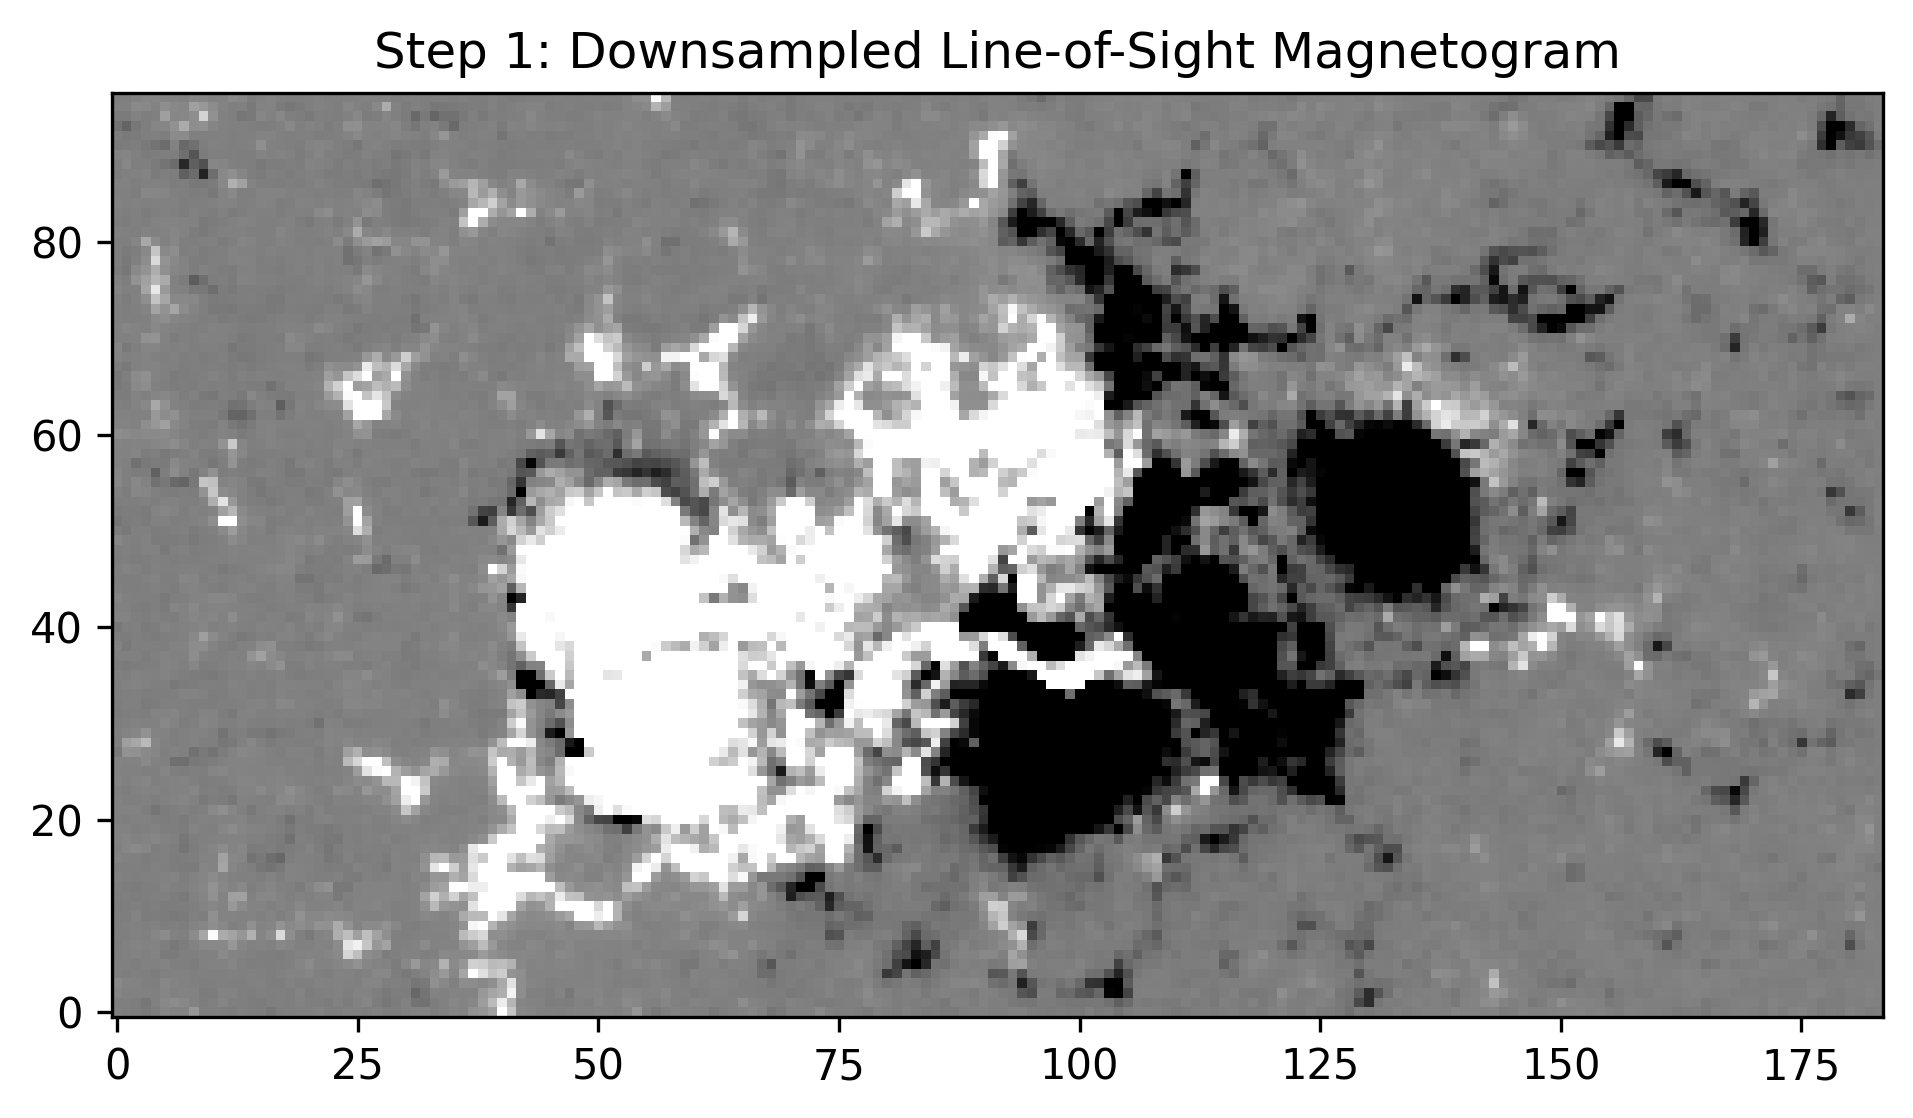

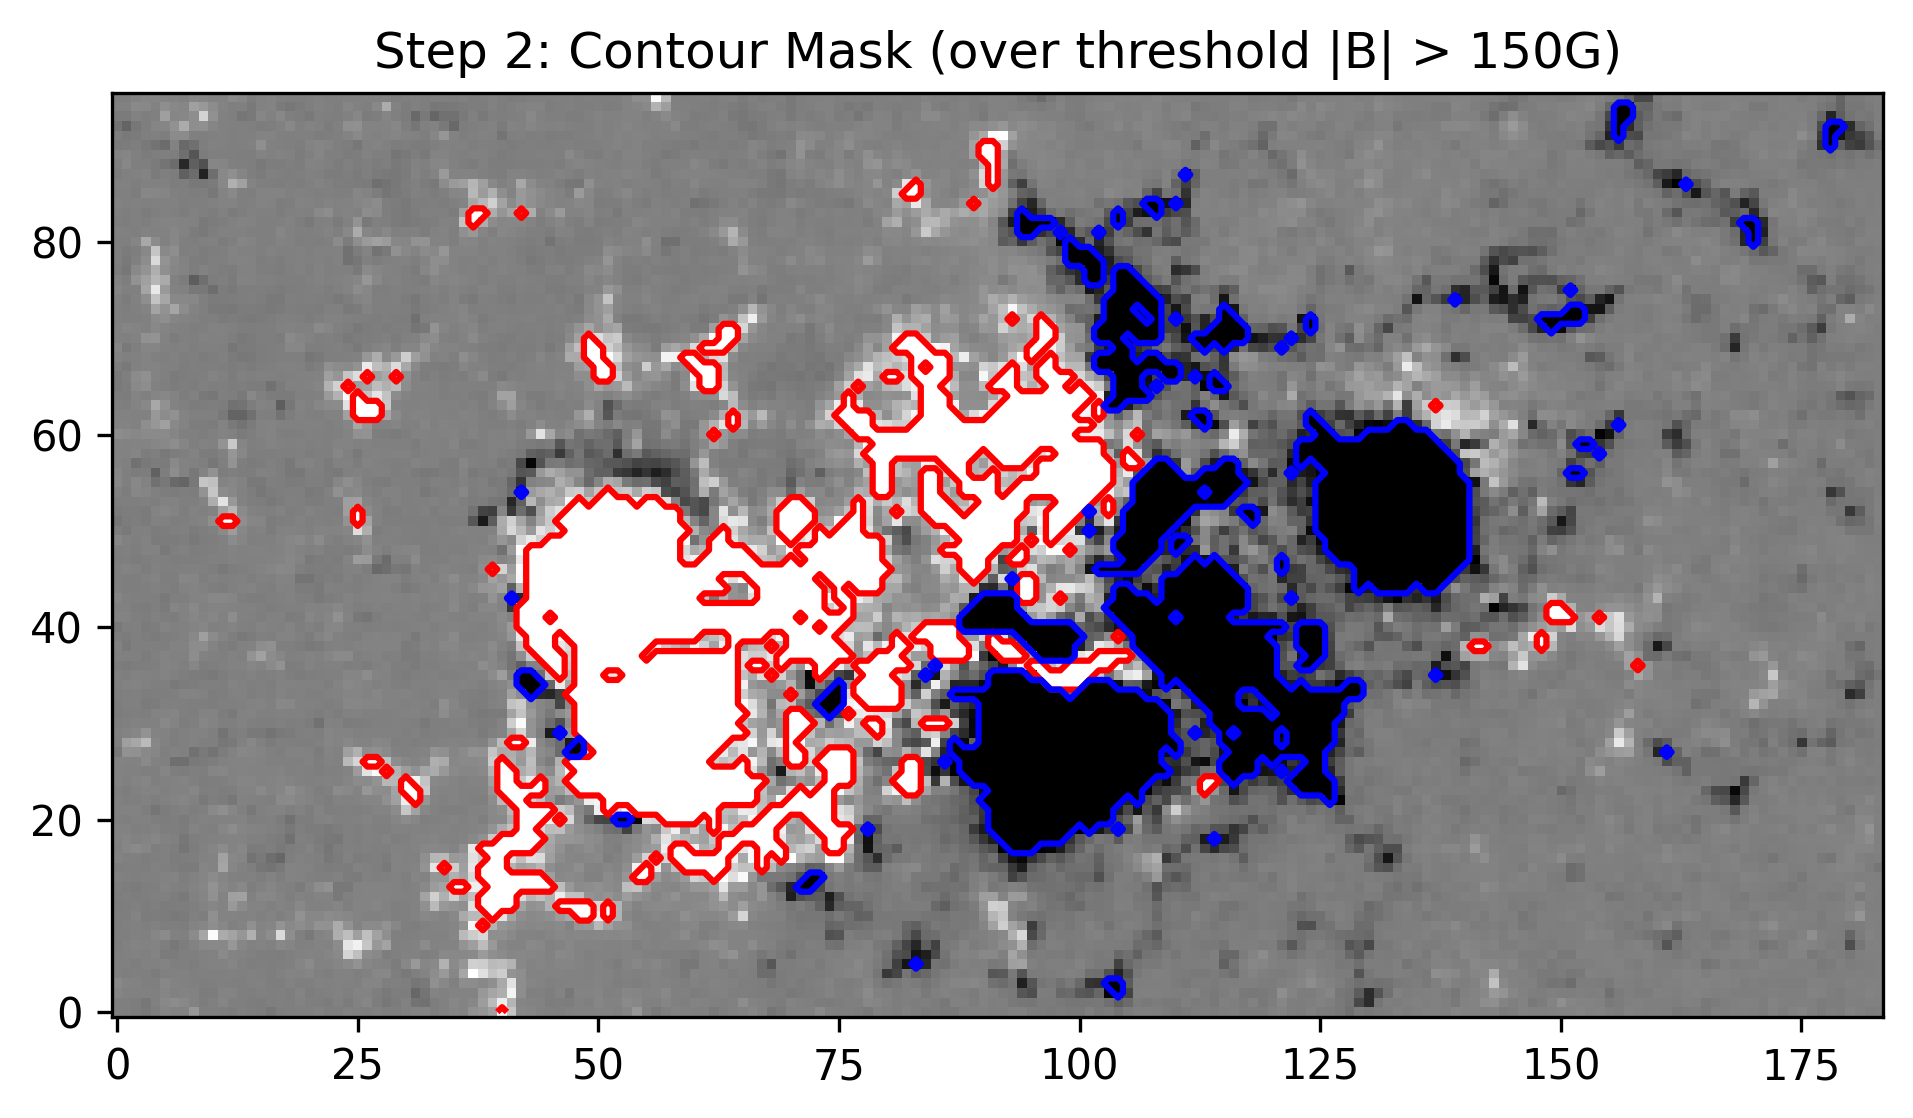

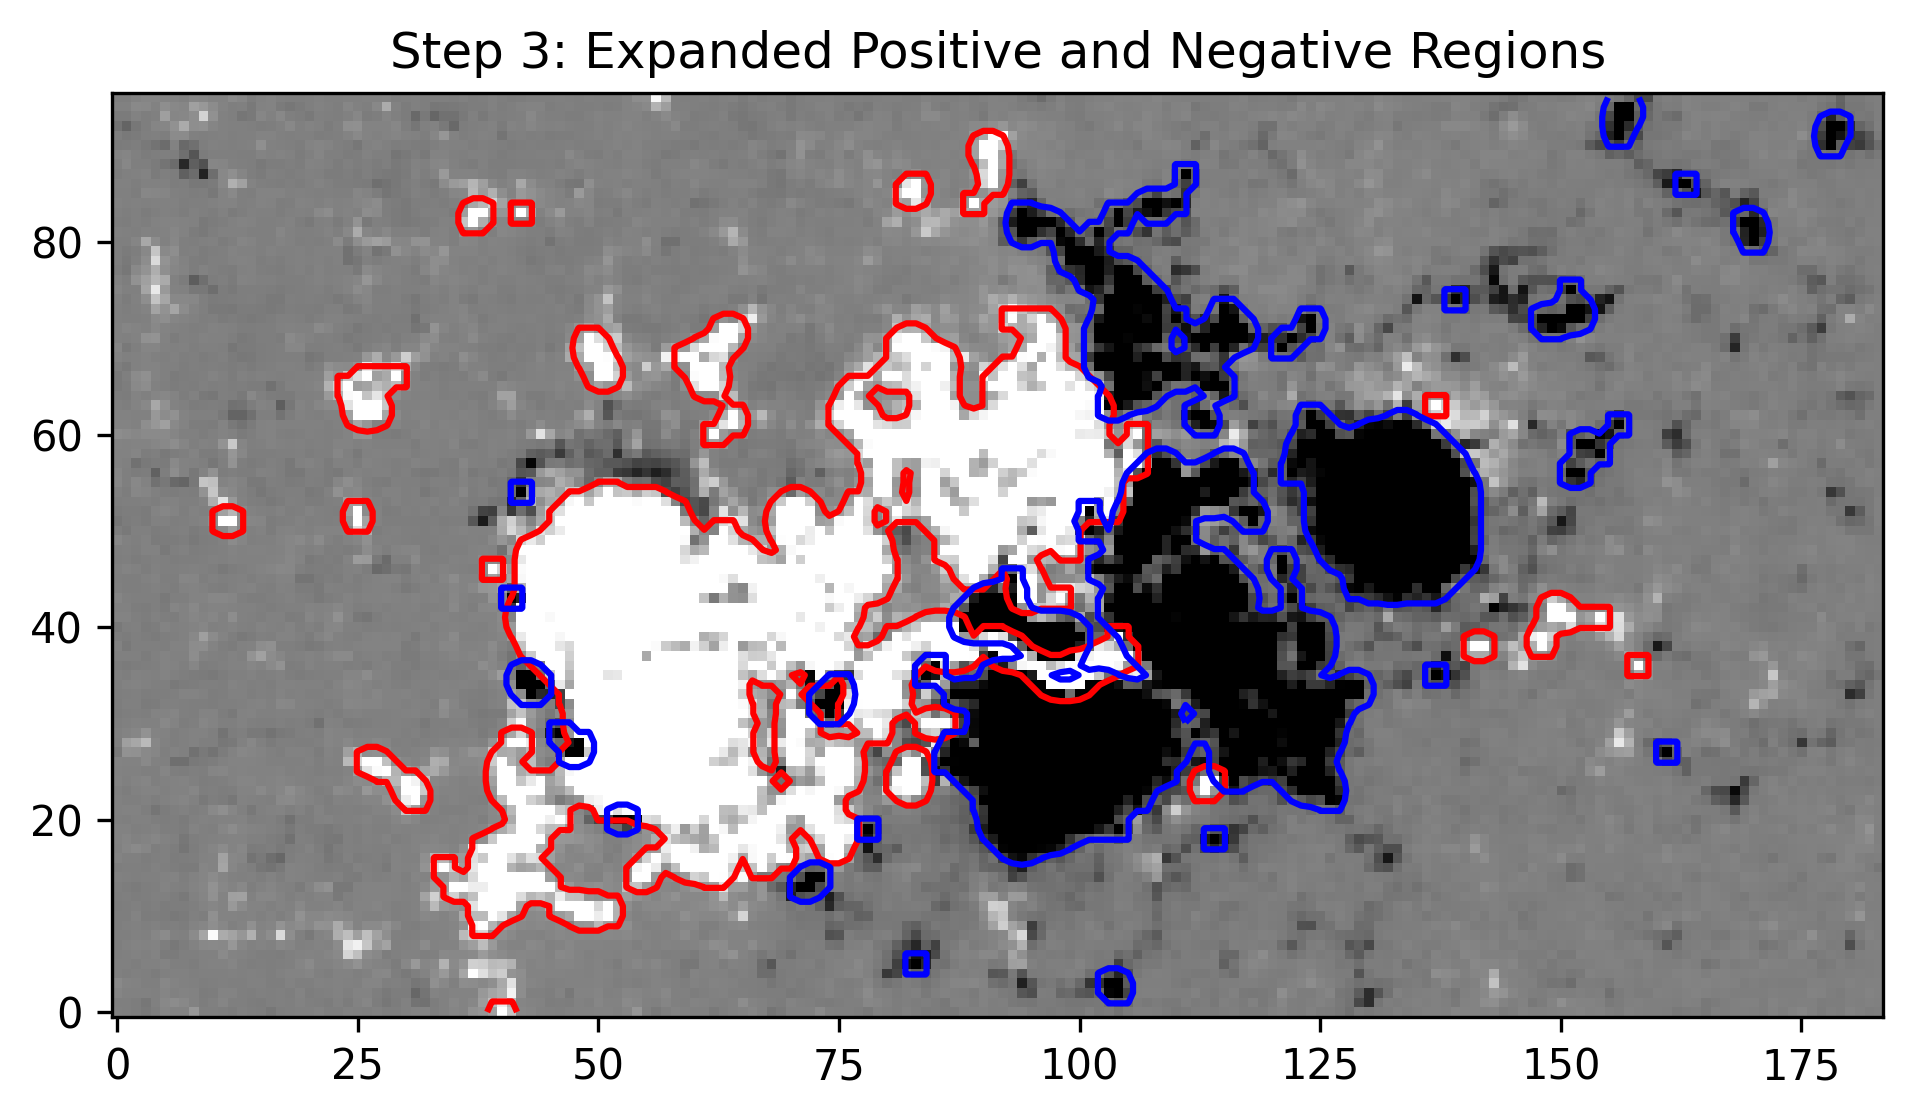

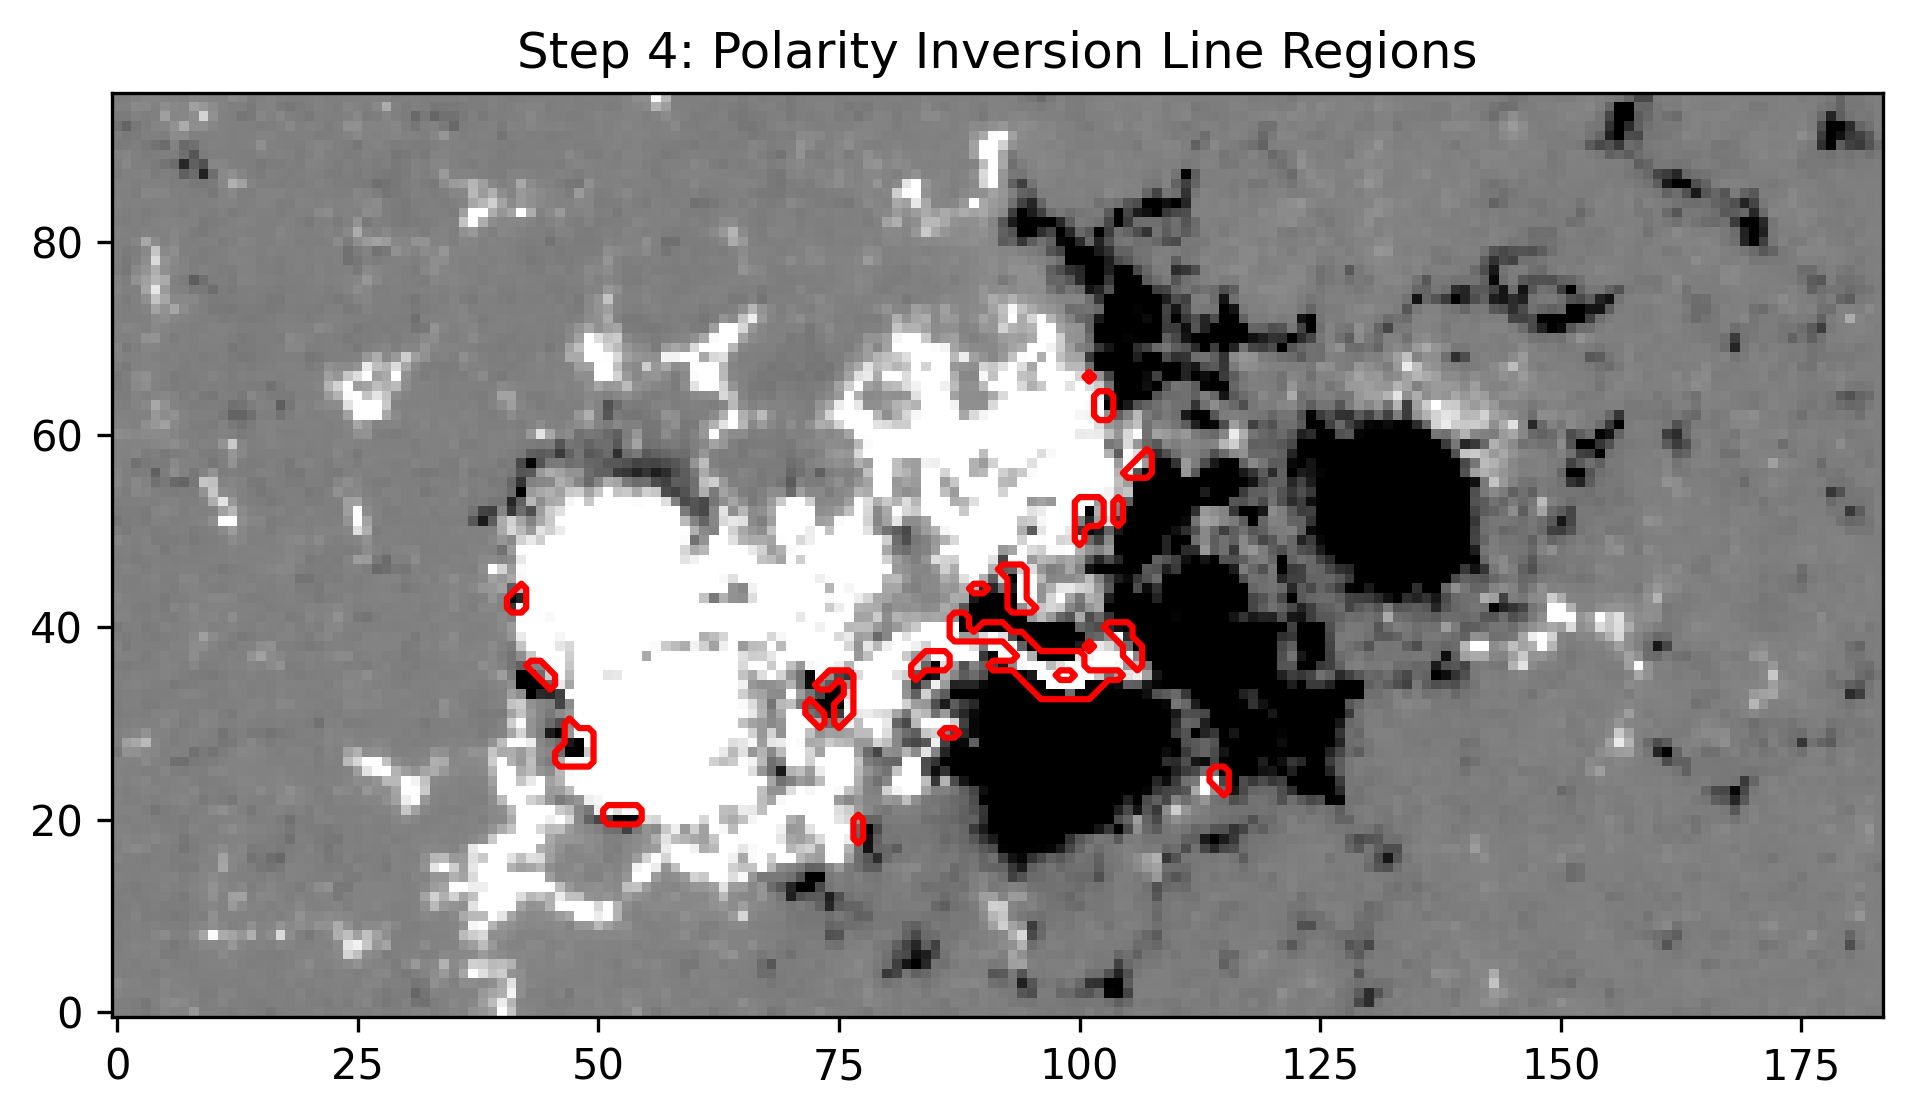

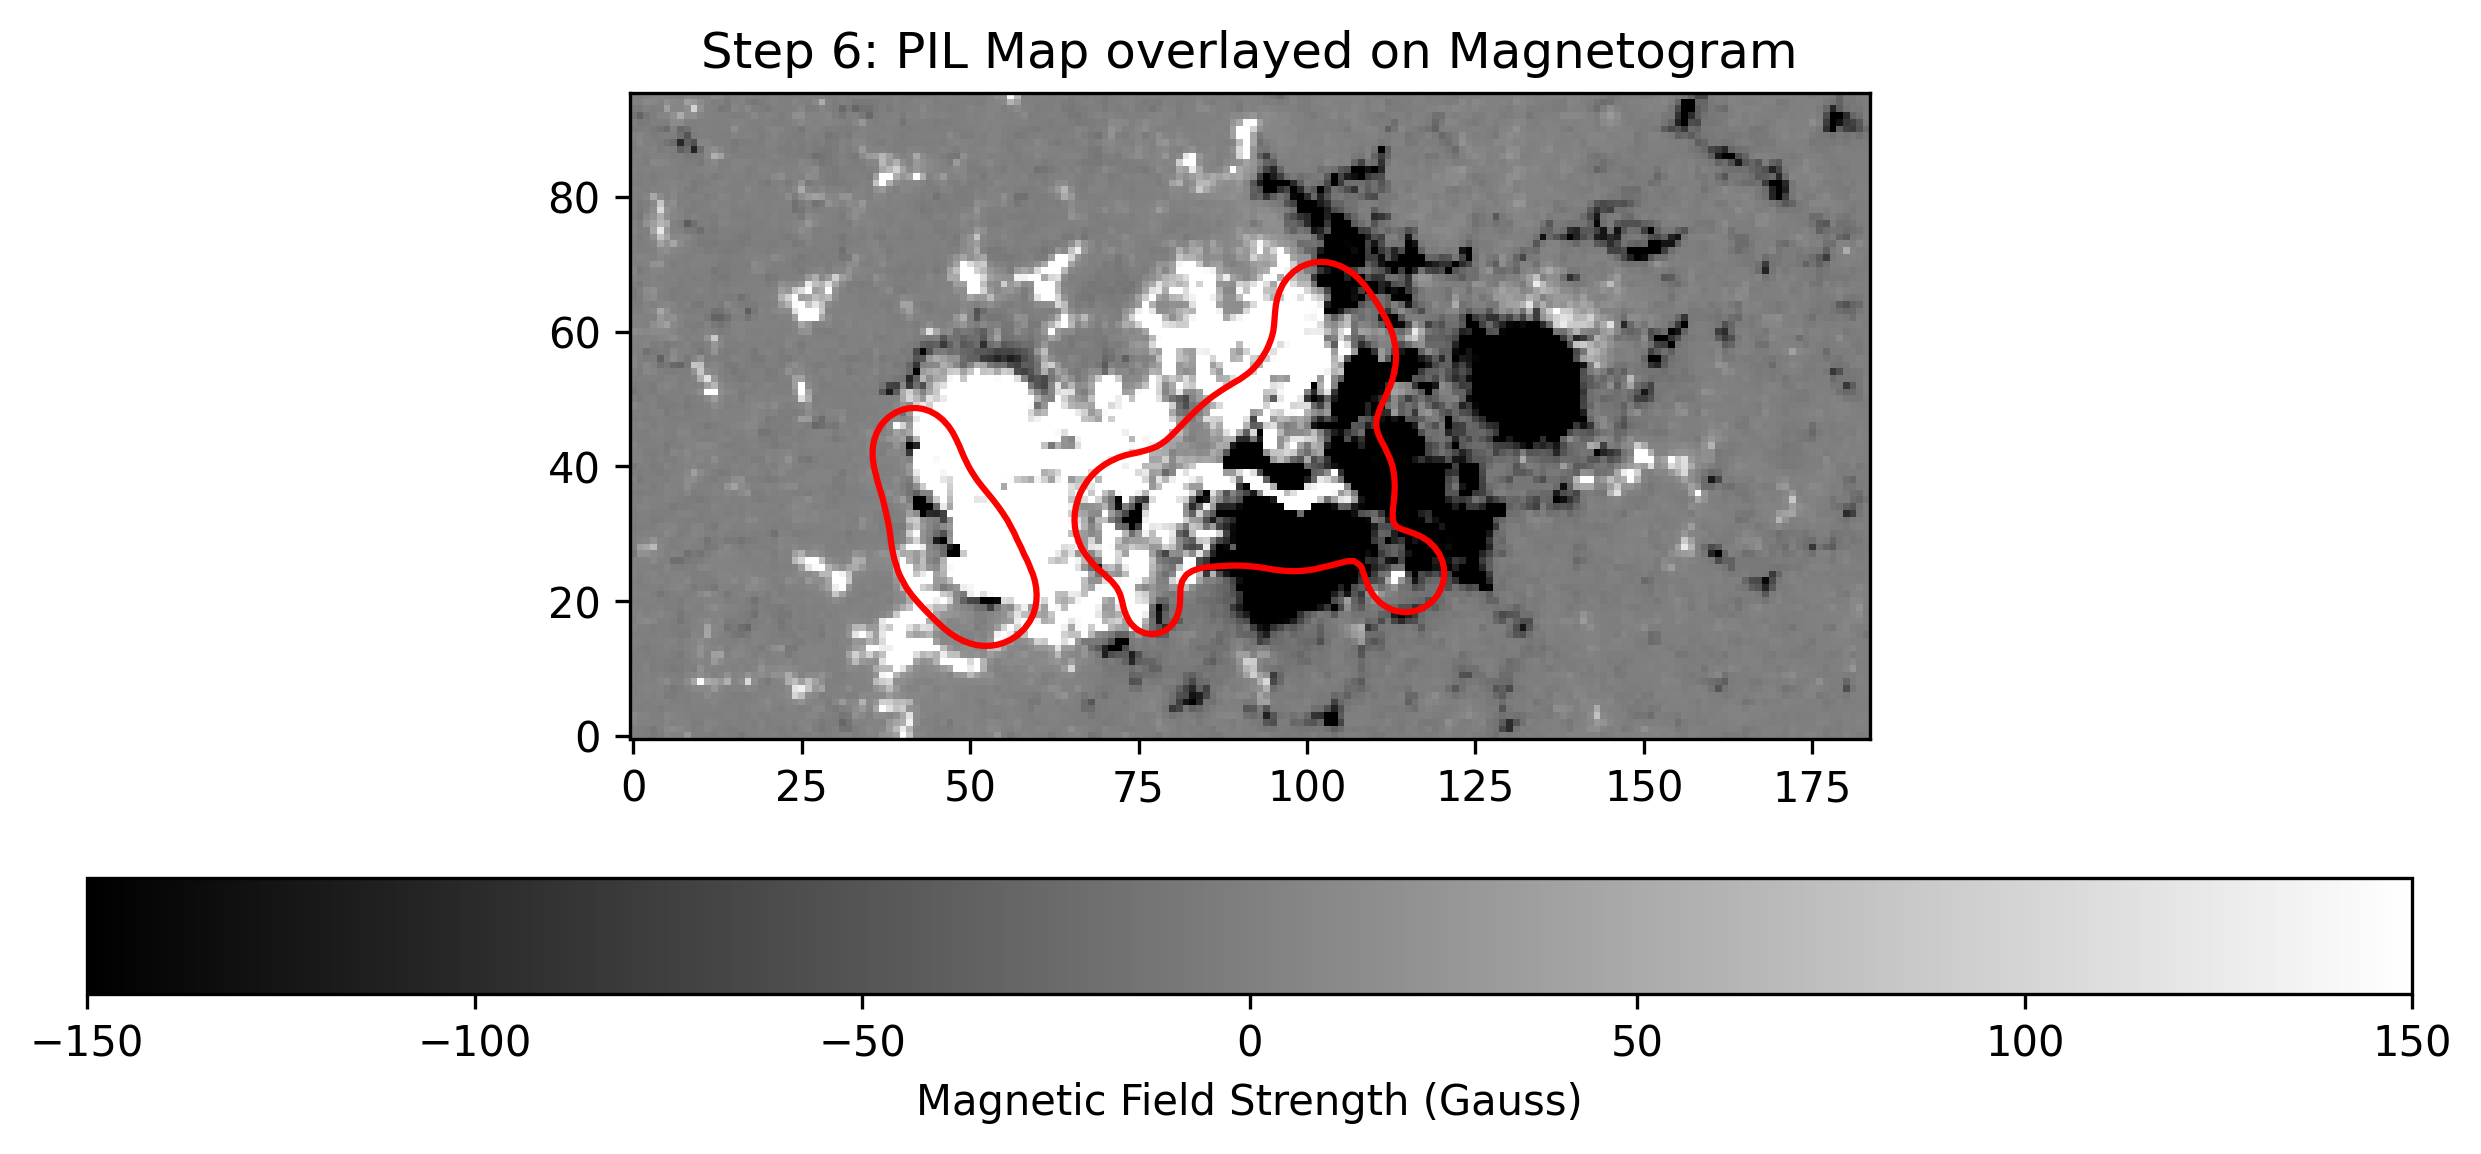

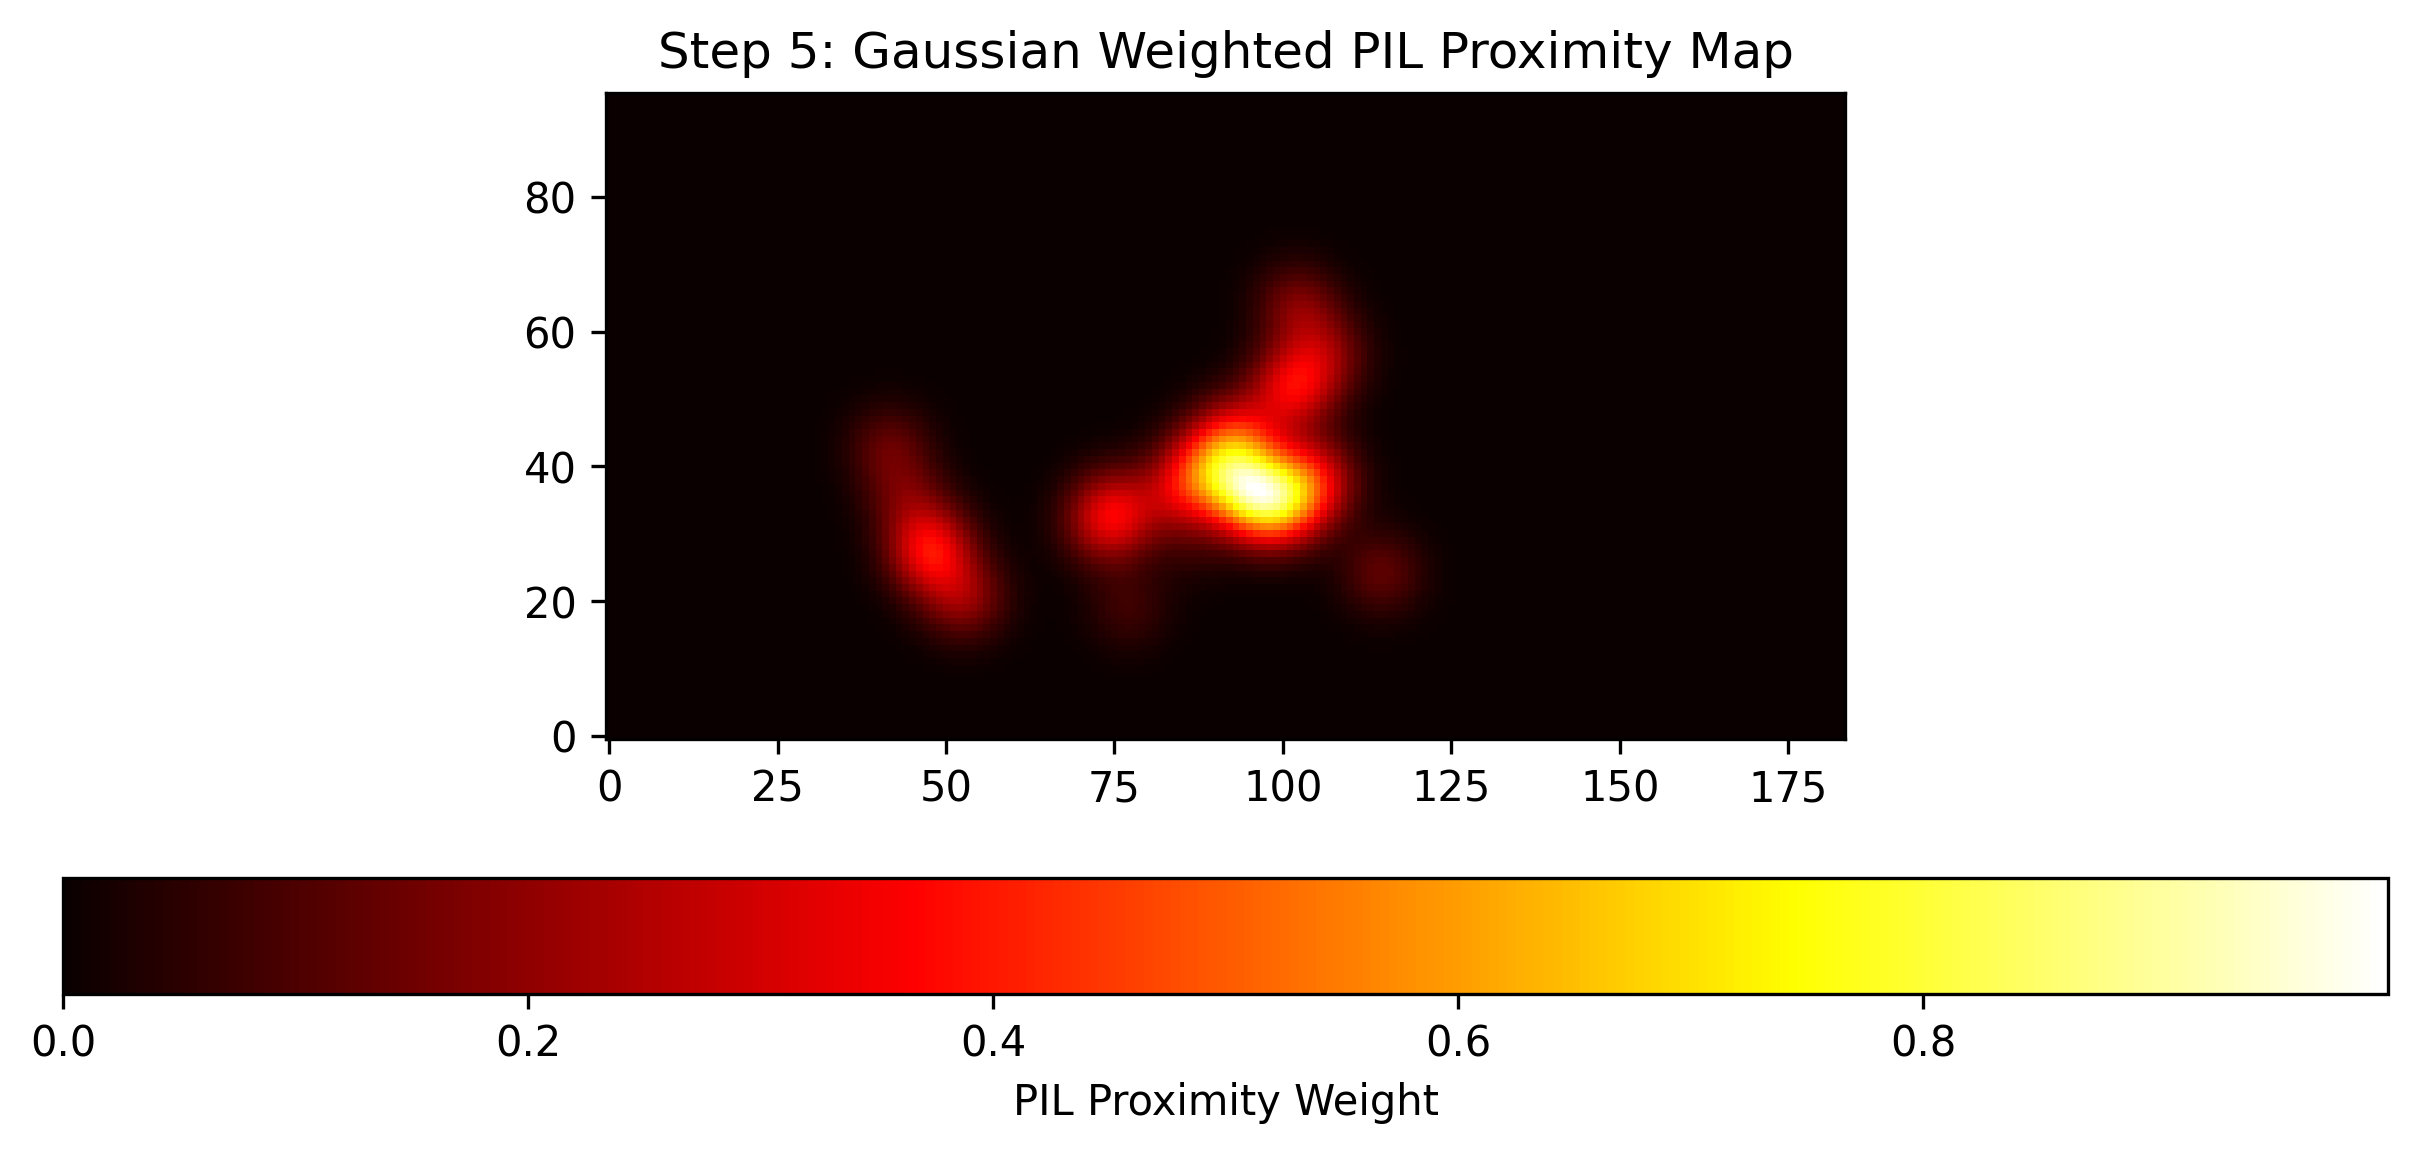

In [19]:
rim,pmap,pmap_full,p1p0,p1p = computePIL(los, cdelt1_arcsec)

In [20]:
non_zero_count = np.count_nonzero(p1p0)
max_value = np.max(p1p0)

print("p1p0 shape:",p1p0.shape)
print("Non-zero entries:", non_zero_count)
print("Max value:", max_value)

p1p0 shape: (96, 184)
Non-zero entries: 1409
Max value: 1.0


In [21]:
non_zero_count = np.count_nonzero(p1p)
max_value = np.max(p1p)

print("p1p shape:",p1p.shape)
print("Non-zero entries:", non_zero_count)
print("Max value:", max_value)

p1p shape: (96, 184)
Non-zero entries: 2665
Max value: 0.9998999999999999
